# Customer Segmentation for Personalized Retail Marketing

#**Bisnis Understanding**

#**Data Understandig**

##**Data Collecting**

##**Load Data**

In [1]:
from google.colab import files
files.upload()

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d vijayuv/onlineretail

Dataset URL: https://www.kaggle.com/datasets/vijayuv/onlineretail
License(s): CC0-1.0
  0% 0.00/7.20M [00:00<?, ?B/s]
100% 7.20M/7.20M [00:00<00:00, 355MB/s]


In [ ]:
!unzip onlineretail.zip -d onlineretail

Archive:  onlineretail.zip
  inflating: onlineretail/OnlineRetail.csv  


In [ ]:
import pandas as pd

data = pd.read_csv('onlineretail/OnlineRetail.csv', encoding='latin1')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


##**cek informasi data**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [ ]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
data.describe(include=['object'])

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


In [ ]:
data['Country'].value_counts().head(10)

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


#**Pembersihan Data**

In [ ]:
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
data = data.dropna(subset=['CustomerID'])

In [ ]:
#ini ga kepake, jadi diganti unknown
data['Description'] = data['Description'].fillna('Unknown')

In [ ]:
data.isnull().sum()


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
#Hapus duplicate
data = data.drop_duplicates()

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data[data['InvoiceNo'].astype(str).str.contains('C', na=False)].head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [ ]:
#hapus data yg transaksi dibatalakan
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]

In [ ]:
#Cek data yg negatif
data[(data['Quantity'] <= 0) | (data['UnitPrice'] <= 0)].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [ ]:
#Cek data yg transaksi dibatalkan
data[data['InvoiceNo'].astype(str).str.contains('C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [ ]:
#InvoiceDate diubah ke Datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


In [ ]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.492832,NaN,22.241836,1713.539549


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


In [ ]:
data.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


## Pembersihan Outlier

In [ ]:
Q1 = data['Quantity'].quantile(0.25)
Q3 = data['Quantity'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['Quantity'] >= Q1 - 1.5 * IQR) & (data['Quantity'] <= Q3 + 1.5 * IQR)]

In [ ]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,367076.000000,367076,367076.000000,367076.000000
mean,7.094719,2011-07-11 02:45:25.328814592,3.240009,15302.780408
min,1.000000,2010-12-01 08:26:00,0.001000,12347.000000
25%,2.000000,2011-04-07 11:30:00,1.250000,13975.000000
50%,4.000000,2011-07-31 15:00:00,1.950000,15182.000000
75%,12.000000,2011-10-20 15:57:00,3.750000,16807.000000
max,27.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,6.670837,NaN,22.972315,1712.040348


In [ ]:
Q1 = data['UnitPrice'].quantile(0.25)
Q3 = data['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['UnitPrice'] >= Q1 - 1.5 * IQR) & (data['UnitPrice'] <= Q3 + 1.5 * IQR)]

In [ ]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,333234.000000,333234,333234.000000,333234.000000
mean,7.550682,2011-07-12 13:40:57.393723136,2.194218,15318.903614
min,1.000000,2010-12-01 08:26:00,0.001000,12347.000000
25%,2.000000,2011-04-08 09:54:00,1.250000,13988.000000
50%,6.000000,2011-08-03 12:06:00,1.650000,15235.000000
75%,12.000000,2011-10-23 11:42:00,2.950000,16814.000000
max,27.000000,2011-12-09 12:50:00,7.500000,18287.000000
std,6.777237,NaN,1.546015,1711.175915


In [ ]:
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


<Axes: title={'center': 'Jumlah Transaksi per Negara'}, xlabel='Country'>

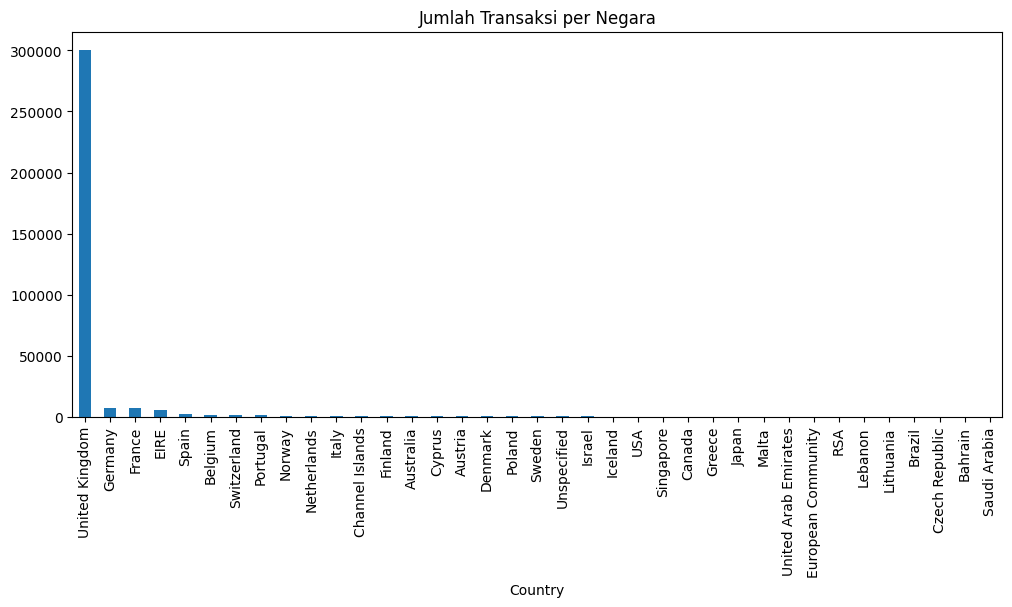

In [ ]:
#Distribusi Negara pembeli
data['Country'].value_counts().plot(kind='bar', figsize=(12,5),
                                    title='Jumlah Transaksi per Negara')

In [ ]:
data['Country'].value_counts()

,count
Country,
United Kingdom,300281
Germany,7448
France,6890
EIRE,5443
Spain,2040
Belgium,1660
Switzerland,1433
Portugal,1252
Norway,772


In [ ]:
data['Country'] = data['Country'].apply(lambda x: x if x == 'United Kingdom' else 'Other')
data['Country'].value_counts()

,count
Country,
United Kingdom,300281
Other,32953


In [ ]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
# Pastikan InvoiceDate dalam format datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Tentukan reference date (snapshot date)
ref_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

# Hitung RFM
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,   # Recency: selisih hari dari transaksi terakhir
    'InvoiceNo': 'nunique',                               # Frequency: jumlah invoice unik
    'TotalPrice': 'sum'                                   # Monetary: total pemasukan customer
})

# Rename kolom agar jelas
rfm = rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
})


In [ ]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,2,7,3314.73
12348.0,249,3,90.20
12349.0,19,1,999.15
12350.0,310,1,294.40
12352.0,36,7,1130.94


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4191.000000,4191.000000,4191.000000
mean,92.493200,4.014794,1025.883127
std,99.908578,7.016195,2200.186051
min,1.000000,1.000000,1.900000
25%,18.000000,1.000000,206.160000
50%,51.000000,2.000000,465.970000
75%,144.000000,4.000000,1127.340000
max,374.000000,196.000000,84980.890000


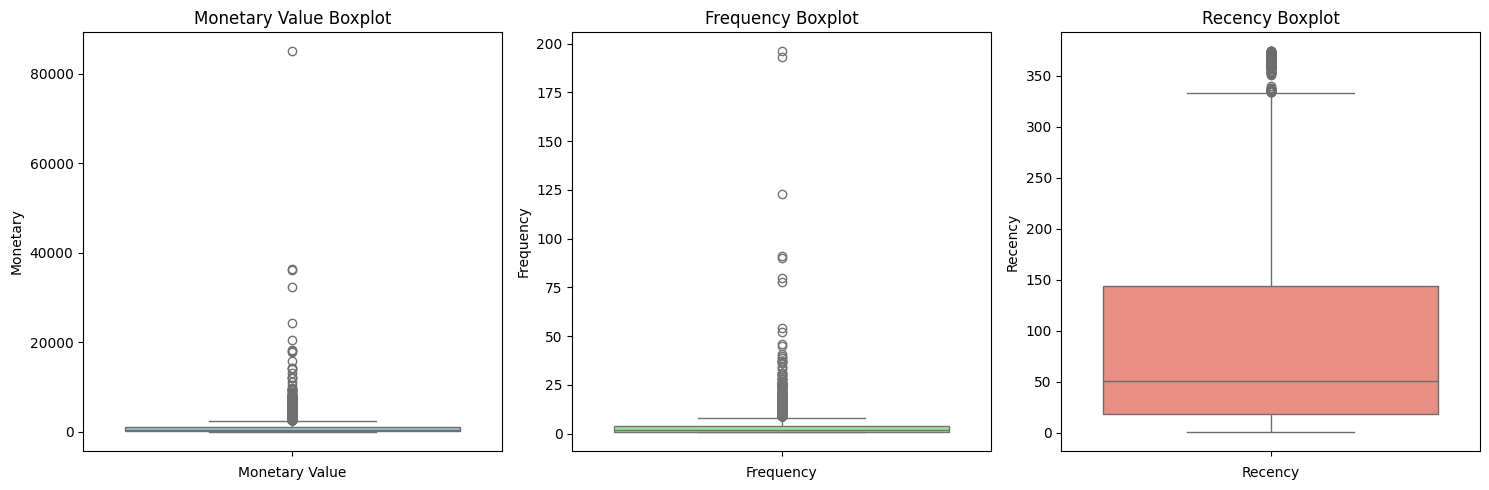

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1, 3, 1)
sns.boxplot(rfm['Monetary'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(rfm['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(rfm['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')
plt.tight_layout()
plt.show()

In [ ]:
# Menggunakan IQR untuk mengatasi outlier Monetary saja (paling ekstrem)
Q1 = rfm['Monetary'].quantile(0.25)
Q3 = rfm['Monetary'].quantile(0.75)
IQR = Q3 - Q1

# Range batas
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Trim Monetary
rfm['Monetary'] = rfm['Monetary'].clip(lower, upper)


In [ ]:
import numpy as np
from sklearn.preprocessing import RobustScaler

# Log transform Monetary
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

rfm_for_scale = rfm[['Recency', 'Frequency', 'Monetary_log']]


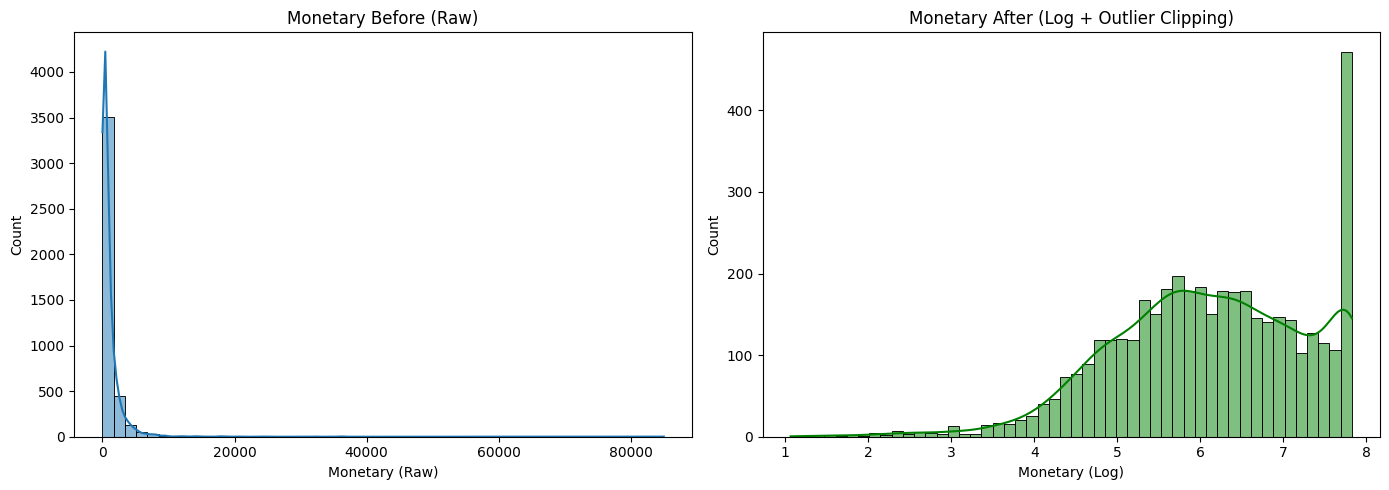

In [ ]:
rfm['Monetary_raw'] = data.groupby('CustomerID')['TotalPrice'].sum().values

plt.figure(figsize=(14,5))

# Before
plt.subplot(1,2,1)
sns.histplot(rfm['Monetary_raw'], kde=True, bins=50)
plt.title("Monetary Before (Raw)")
plt.xlabel("Monetary (Raw)")

# After
plt.subplot(1,2,2)
sns.histplot(rfm['Monetary_log'], kde=True, bins=50, color='green')
plt.title("Monetary After (Log + Outlier Clipping)")
plt.xlabel("Monetary (Log)")

plt.tight_layout()
plt.show()

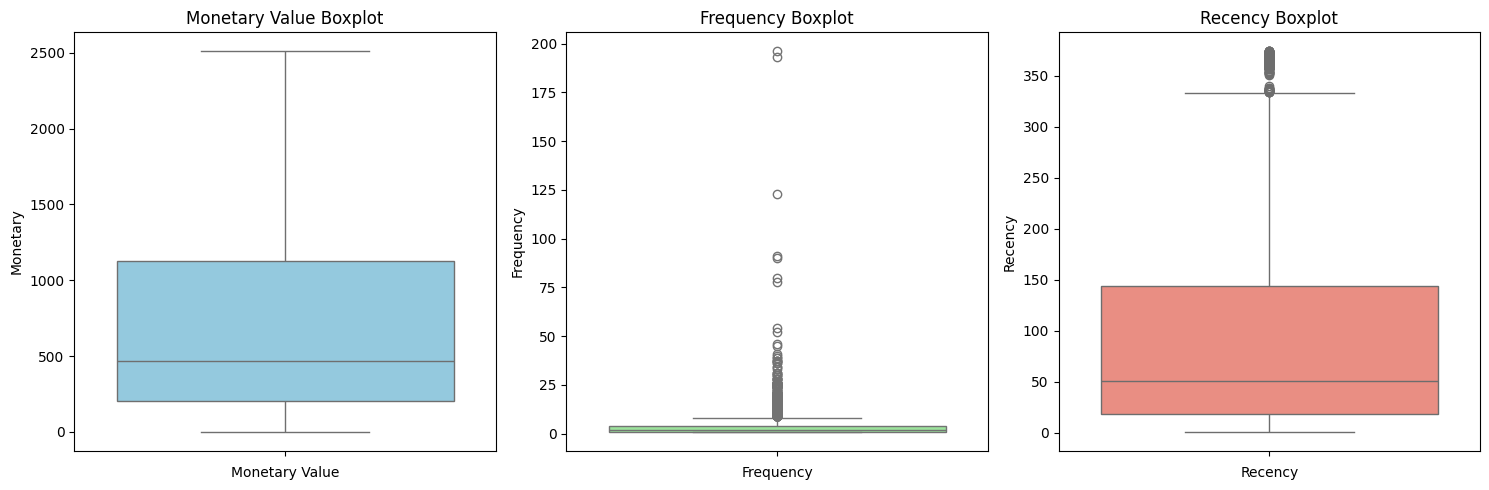

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1, 3, 1)
sns.boxplot(rfm['Monetary'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(rfm['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(rfm['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')
plt.tight_layout()
plt.show()

In [ ]:
# RobustScaler tahan outlier
scaler = RobustScaler()
rfm_scaled = scaler.fit_transform(rfm_for_scale)

Modelling K-Means Cluster 3 5 PCA(2)

In [ ]:
#Model KMEANS + PCA
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_for_scale)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(rfm_pca)

from sklearn.metrics import silhouette_score
sil_kmeans_pca = silhouette_score(rfm_pca, labels)
print("Silhouette Score (KMeans + PCA):", sil_kmeans_pca)


Silhouette Score (KMeans + PCA): 0.6702588217414754


In [ ]:
#Model GMM
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3, random_state=42)
rfm['Cluster_GMM'] = gmm.fit_predict(rfm_for_scale)

sil_gmm = silhouette_score(rfm_for_scale, rfm['Cluster_GMM'])
print("Silhouette Score (GMM):", sil_gmm)


Silhouette Score (GMM): -0.1329457694954897


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

print("Testing berbagai nilai k:\n")

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    temp_labels = km.fit_predict(rfm_pca)
    score = silhouette_score(rfm_pca, temp_labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

km3 = KMeans(n_clusters=3, random_state=42)
labels_3 = km3.fit_predict(rfm_pca)

rfm['Cluster'] = labels_3


Testing berbagai nilai k:

K = 2, Silhouette Score = 0.7357
K = 3, Silhouette Score = 0.6703
K = 4, Silhouette Score = 0.5962
K = 5, Silhouette Score = 0.5926
K = 6, Silhouette Score = 0.5781
K = 7, Silhouette Score = 0.5628
K = 8, Silhouette Score = 0.5479
K = 9, Silhouette Score = 0.5148


In [ ]:
#Model Agglomerative
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(rfm_for_scale)
sil_agg = silhouette_score(rfm_for_scale, labels_agg)

print("Silhouette:", sil_agg)

Silhouette: 0.669916877502391


In [ ]:
print(pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())

[0.99532358 0.00458439]
Total: 0.9999079704344835


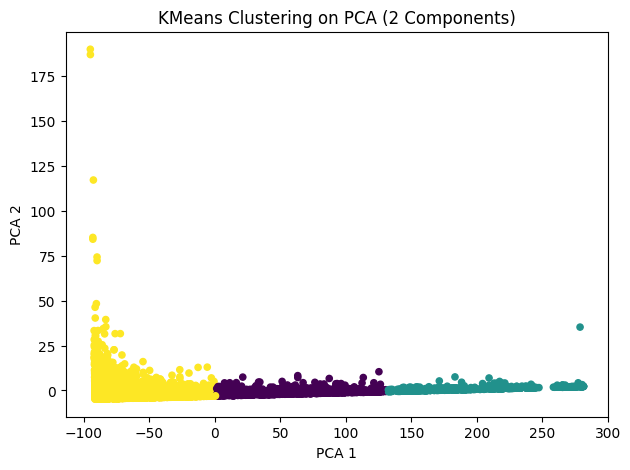

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c=labels, cmap='viridis', s=20)
plt.title("KMeans Clustering on PCA (2 Components)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

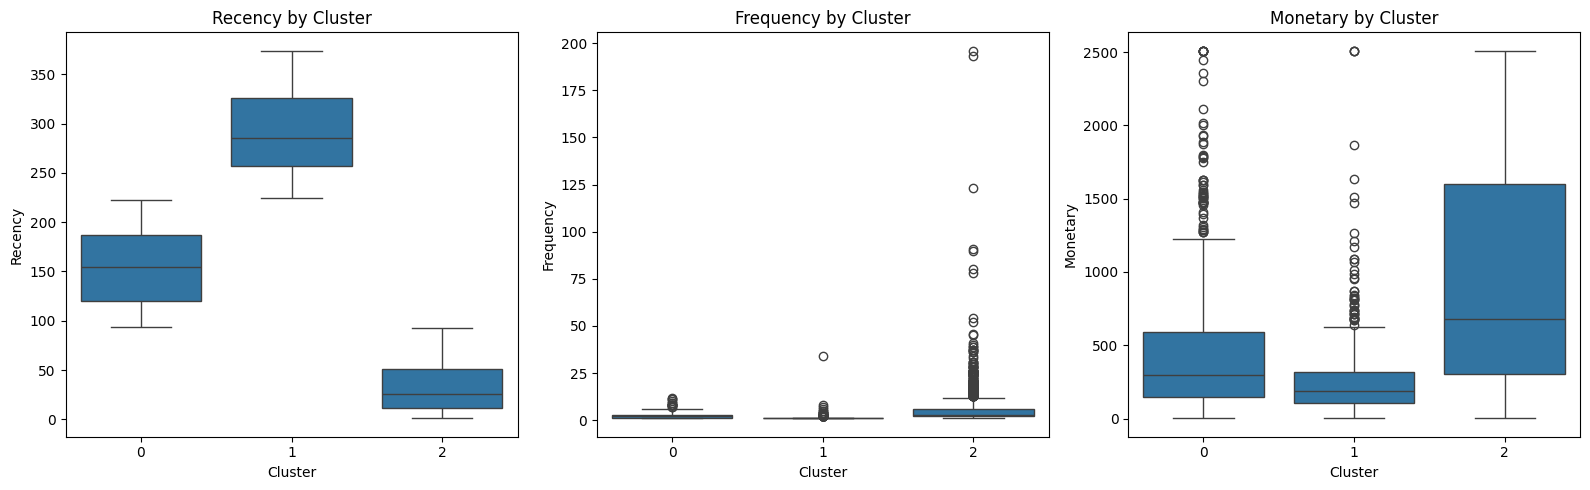

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,5))

plt.subplot(1,3,1)
sns.boxplot(x='Cluster', y='Recency', data=rfm)
plt.title('Recency by Cluster')

plt.subplot(1,3,2)
sns.boxplot(x='Cluster', y='Frequency', data=rfm)
plt.title('Frequency by Cluster')

plt.subplot(1,3,3)
sns.boxplot(x='Cluster', y='Monetary', data=rfm)
plt.title('Monetary by Cluster')

plt.tight_layout()
plt.show()


#INTERPRETASI HASIL CLUSTERING


In [ ]:
rfm['Cluster'].value_counts()


,count
Cluster,
2,2822
0,763
1,606


In [ ]:
numeric_cols = ['Recency', 'Frequency', 'Monetary']
rfm.groupby("Cluster")[numeric_cols].agg(["mean", "min", "max"])

Recency           Frequency             Monetary               
               mean  min  max      mean min  max        mean   min      max
Cluster                                                                    
0        154.846658   94  223  2.133683   1   12  458.538547  2.90  2509.11
1        293.879538  225  374  1.318482   1   34  263.405215  2.95  2509.11
2         32.388377    1   93  5.102410   1  196  992.924076  1.90  2509.11

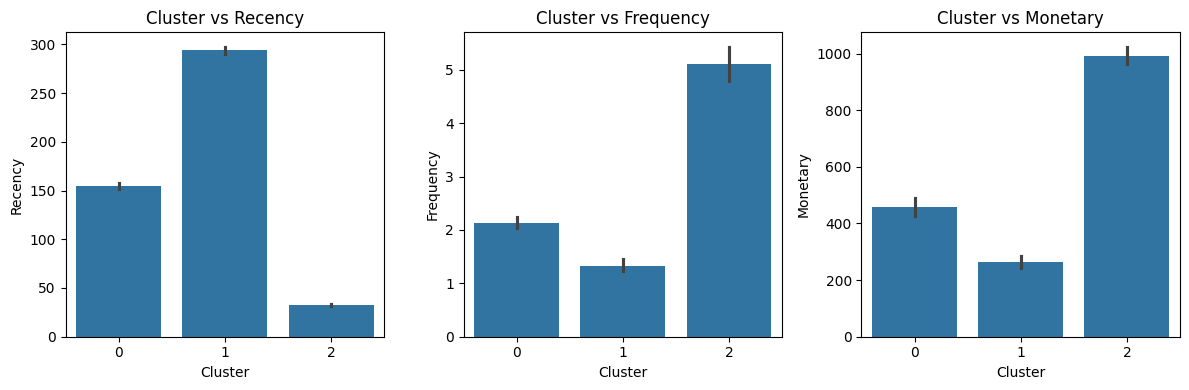

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
for i, col in enumerate(['Recency','Frequency','Monetary']):
    plt.subplot(1,3,i+1)
    sns.barplot(x='Cluster', y=col, data=rfm)
    plt.title(f'Cluster vs {col}')
plt.tight_layout()
plt.show()


##Interpretasi Cluster 0

**Rata-Rata :**
* Recency: 154 hari (tidak terlalu lama, tidak terlalu baru)
* Frequency: 2.13 transaksi (Menengah)
* Monetary: 458.5 (nilai pembelian menengah)

**Rentang Nilai:**
* Recency: 94 – 223
* Frequency: 1 – 12
* Monetary: 2.90 – 2509

**Analisis:**

Cluster 0 didominasi oleh pelanggan yang:
* Bertransaksi secara rutin namun tidak terlalu sering
* Memiliki nilai belanja menengah
* Tidak terlalu baru melakukan transaksi, tetapi juga tidak terlalu lama
* Terkadang melakukan transaksi bernilai tinggi (karena max Monetary cukup besar)

**Interpretasi:**
Kelompok ini adalah pelanggan stabil yang kadang melakukan pembelian besar tetapi tidak terlalu sering. Mereka potensial untuk ditingkatkan menjadi pelanggan bernilai tinggi melalui kampanye loyalty atau upselling. Namun bisa juga turun jika tidak dipertahankan.

**Strategi yang cocok:**
* Promo periodik yang tidak terlalu agresif
* Reminder email
* Program “reactivation” ringan
* Bundling produk

##Interpretasi Cluster 1

**Rata-Rata :**
* Recency: 293.87 hari (Tinggi, Banyak yang sudah lama tidak belanja)
* Frequency: 1.31 transaksi (Rendah, Jarang Kembali)
* Monetary: 263.4 (rendah–menengah, Belanja Kecil)

**Rentang Nilai:**
* Recency: 255 – 374
* Frequency: 1 – 8
* Monetary: 2.95 – 2509

**Analisis:**

Cluster 1 didominasi oleh pelanggan yang:
* Sudah lama tidak bertransaksi (recency tertinggi)
* Paling jarang melakukan transaksi
* Nilai pembeliannya rendah
* Berpotensi churn / hilang

**Interpretasi:**
Ini adalah pelanggan berisiko, kelompok dengan aktivitas terendah dan jarang kembali. Kontribusi terhadap pendapatan paling kecil. Perlu strategi re-engagement agar tidak hilang selamanya

**Strategi yang cocok:**
* Diskon besar untuk menarik kembali
* SMS/Email re-activation
* Promo khusus satu kali untuk “wake-up call”
* Survey untuk memahami alasan tidak kembali





##Interpretasi Cluster 2

**Rata-Rata :**
* Recency: 32.38 hari (yang terbaru/Rendah)
* Frequency: 5.10 (tertinggi)
* Monetary: 992.9 (tertinggi)

**Rentang Nilai:**
* Recency: 1 – 196
* Frequency: 1 – 196
* Monetary: 1.90 – 2509

**Analisis:**

Cluster 2 didominasi oleh pelanggan yang:
* Paling aktif bertransaksi
* Paling sering melakukan pembelian
* Memiliki nilai pembelian terbesar
* Baru saja melakukan transaksi (recency rendah)

**Interpretasi:**
Mereka adalah pelanggan utama (VIP / loyal customer) yang sangat berharga dan paling penting. Memberikan kontribusi pendapatan terbesar. Sangat responsif terhadap promosi upselling & loyalty program.

**Strategi yang cocok:**
* Loyalty rewards
* Membership / VIP program
* Personalized offers
* Early access promo





In [ ]:
rfm['PCA1'] = rfm_pca[:,0]
rfm['PCA2'] = rfm_pca[:,1]


NameError: name 'rfm_pca' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ========================================
# 1. Prepare Data
# ========================================

clusters = rfm["Cluster"]
rec = rfm["Recency"]
freq = rfm["Frequency"]
mon = rfm["Monetary"]

# Radar preparation
rfm_means = rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()
scaler = MinMaxScaler()
radar_norm = scaler.fit_transform(rfm_means)
categories = ["Recency", "Frequency", "Monetary"]

# Snake plot preparation
scaler2 = StandardScaler()
rfm_std = scaler2.fit_transform(rfm[["Recency","Frequency","Monetary"]])
rfm_std = rfm_std - rfm_std.mean(axis=0)
rfm_std_df = rfm.copy()
rfm_std_df[["R","F","M"]] = rfm_std
snake = rfm_std_df.groupby("Cluster")[["R","F","M"]].mean().T

# ========================================
# 2. CREATE DASHBOARD IN A SINGLE WINDOW
# ========================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Customer Segmentation Dashboard (RFM + KMeans)", fontsize=18, y=0.95)

# ---------- PCA Plot ----------
ax1 = plt.subplot(2,3,1)
scatter = ax1.scatter(rfm_pca[:,0], rfm_pca[:,1], c=clusters, cmap='viridis', s=20)
ax1.set_title("PCA Scatter Plot")
ax1.set_xlabel("PCA 1")
ax1.set_ylabel("PCA 2")

# ---------- Pie Chart ----------
ax2 = plt.subplot(2,3,2)
cluster_counts = rfm["Cluster"].value_counts()
ax2.pie(cluster_counts, labels=cluster_counts.index, autopct="%1.1f%%", startangle=90)
ax2.set_title("Cluster Distribution")

# ---------- Radar Chart ----------
ax3 = plt.subplot(2,3,3, polar=True)
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

for idx, row in enumerate(radar_norm):
    values = row.tolist()
    values += values[:1]
    ax3.plot(angles, values, label=f"Cluster {idx}")
    ax3.fill(angles, values, alpha=0.1)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories)
ax3.set_title("Radar Chart Per Cluster")
ax3.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

# ---------- Boxplots ----------
ax4 = plt.subplot(2,3,4)
sns.boxplot(x=clusters, y=rec, ax=ax4)
ax4.set_title("Recency Boxplot")

ax5 = plt.subplot(2,3,5)
sns.boxplot(x=clusters, y=freq, ax=ax5)
ax5.set_title("Frequency Boxplot")

ax6 = plt.subplot(2,3,6)
sns.boxplot(x=clusters, y=mon, ax=ax6)
ax6.set_title("Monetary Boxplot")

plt.tight_layout()
plt.show()
